In [ ]:
import pandas as pd
import numpy as np
#  1. Chargement de dataset 
data =pd.read_csv("fraud_dataset.csv")
print("apercu:")
print(data.head())

apercu:
        amount  time_delta  device_score  customer_age  transaction_freq  \
0  1750.963549  125.980447      0.764416            53                30   
1  4936.091851   97.763624      0.241543            68                24   
2  3187.479320   99.532542      0.347859            72                18   
3  2886.858745  180.052860      0.950977            18                30   
4   163.747040  208.118233      0.100508            31                26   

   risk_country_id  card_score  is_fraud  
0                1    0.792335         0  
1                1    0.770824         0  
2                4    0.555026         1  
3                2    0.482169         0  
4                1    0.841608         0  


In [ ]:
# X contient toutes les colonnes SAUF la cible
X = data.drop('is_fraud', axis=1)
# y contient uniquement la colonne cible
y = data['is_fraud']

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_grid = {'n_neighbors': np.arange(1, 21)}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
grid_knn.fit(X_train_scaled, y_train)
best_k = grid_knn.best_params_['n_neighbors']
print(f"Meilleur paramètre K trouvé : {best_k}")

Meilleur paramètre K trouvé : 5


In [ ]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)
# Calcul des métriques
print("--- Résultats du Modèle KNN ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print("\nMatrice de Confusion :")
print(confusion_matrix(y_test, y_pred))

--- Résultats du Modèle KNN ---
Accuracy  : 0.9350
Precision : 0.8333
Recall    : 0.4762

Matrice de Confusion :
[[177   2]
 [ 11  10]]


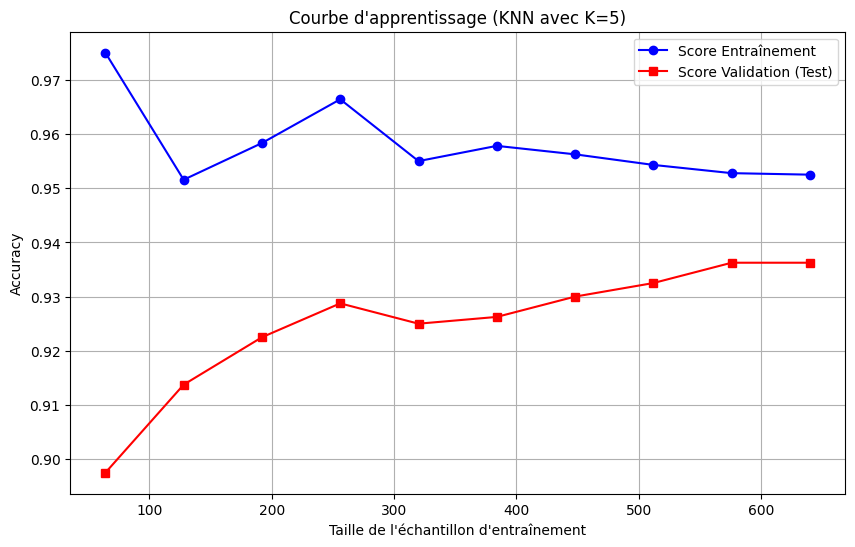

In [ ]:
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    # Calcul des moyennes et écart-types
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Score Entraînement', color='blue', marker='o')
    plt.plot(train_sizes, test_mean, label='Score Validation (Test)', color='red', marker='s')
    plt.title(f'Courbe d\'apprentissage (KNN avec K={best_k})')
    plt.xlabel('Taille de l\'échantillon d\'entraînement')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()
plot_learning_curve(final_knn, X_train_scaled, y_train)

--- SVM LINÉAIRE ---
Meilleur paramètre : {'C': 0.1}
Accuracy Train : 0.9400 | Accuracy Test : 0.9250


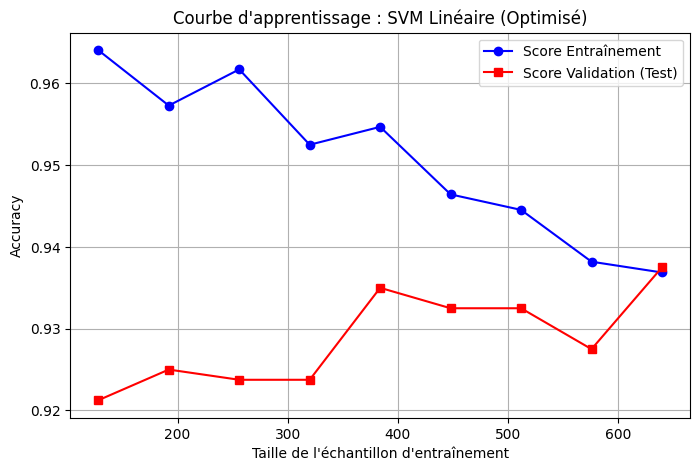

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
param_grid_lin = {'C': [0.1, 1, 10, 100]}
grid_lin = GridSearchCV(SVC(kernel='linear'), param_grid_lin, cv=5, scoring='accuracy', n_jobs=-1)
grid_lin.fit(X_train_scaled, y_train)
best_svm_lin = grid_lin.best_estimator_
acc_train_lin = best_svm_lin.score(X_train_scaled, y_train)
acc_test_lin = best_svm_lin.score(X_test_scaled, y_test)
print(f"--- SVM LINÉAIRE ---")
print(f"Meilleur paramètre : {grid_lin.best_params_}")
print(f"Accuracy Train : {acc_train_lin:.4f} | Accuracy Test : {acc_test_lin:.4f}")
import warnings
warnings.filterwarnings('ignore')
plot_individual_learning_curve(best_svm_lin, X_train_scaled, y_train, "SVM Linéaire (Optimisé)")

--- SVM POLYNOMIAL ---
Meilleurs paramètres : {'C': 1, 'degree': 3}
Accuracy Train : 0.9537 | Accuracy Test : 0.9350


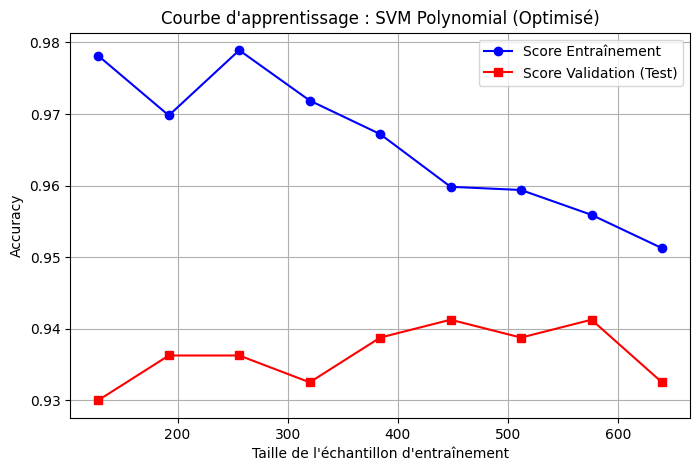

In [ ]:
#  Définition des paramètres
param_grid_poly = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4]
}
# gridsearch
grid_poly = GridSearchCV(SVC(kernel='poly'), param_grid_poly, cv=5, scoring='accuracy', n_jobs=-1)
grid_poly.fit(X_train_scaled, y_train)
# 3. Résultats
best_svm_poly = grid_poly.best_estimator_
acc_train_poly = best_svm_poly.score(X_train_scaled, y_train)
acc_test_poly = best_svm_poly.score(X_test_scaled, y_test)
print(f"--- SVM POLYNOMIAL ---")
print(f"Meilleurs paramètres : {grid_poly.best_params_}")
print(f"Accuracy Train : {acc_train_poly:.4f} | Accuracy Test : {acc_test_poly:.4f}")
import warnings
warnings.filterwarnings('ignore')
plot_individual_learning_curve(best_svm_poly, X_train_scaled, y_train, "SVM Polynomial (Optimisé)")

--- SVM RBF ---
Meilleurs paramètres : {'C': 100, 'gamma': 0.01}
Accuracy Train : 0.9550 | Accuracy Test : 0.9150


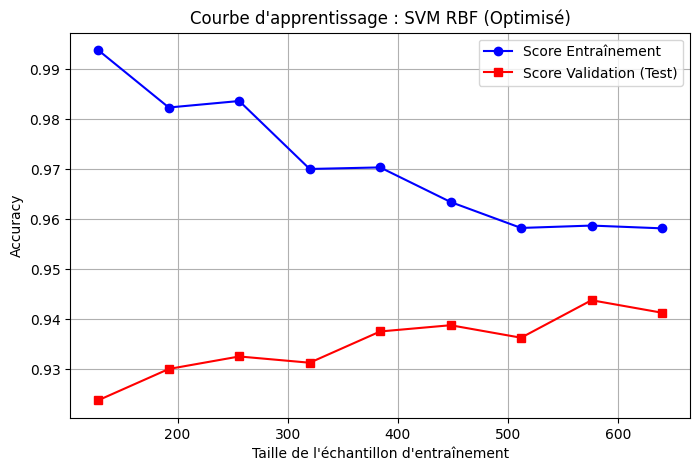

In [ ]:
# 1. Définition des paramètres
param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001]
}
# 2. Recherche
grid_rbf = GridSearchCV(SVC(kernel='rbf'), param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rbf.fit(X_train_scaled, y_train)
# 3. Résultats
best_svm_rbf = grid_rbf.best_estimator_
acc_train_rbf = best_svm_rbf.score(X_train_scaled, y_train)
acc_test_rbf = best_svm_rbf.score(X_test_scaled, y_test)
print(f"--- SVM RBF ---")
print(f"Meilleurs paramètres : {grid_rbf.best_params_}")
print(f"Accuracy Train : {acc_train_rbf:.4f} | Accuracy Test : {acc_test_rbf:.4f}")
import warnings
warnings.filterwarnings('ignore')
plot_individual_learning_curve(best_svm_rbf, X_train_scaled, y_train, "SVM RBF (Optimisé)")

In [266]:
import pandas as pd

data = {
    'Noyau': ['Linéaire', 'Polynomial', 'RBF'],
    'Accuracy Train': [accuracy_score(y_train, y_train_pred_lin), accuracy_score(y_train, y_train_pred_poly), accuracy_score(y_train, y_train_pred_rbf)],
    'Accuracy Test': [accuracy_score(y_test, y_test_pred_lin), accuracy_score(y_test, y_test_pred_poly), accuracy_score(y_test, y_test_pred_rbf)],
    'Recall (Test)': [recall_score(y_test, y_test_pred_lin), recall_score(y_test, y_test_pred_poly), recall_score(y_test, y_test_pred_rbf)]
}

df_comp = pd.DataFrame(data)
print(df_comp)

        Noyau  Accuracy Train  Accuracy Test  Recall (Test)
0    Linéaire         0.93750          0.925       0.523810
1  Polynomial         0.95375          0.935       0.428571
2         RBF         0.95500          0.940       0.476190


--- ARBRE DE DÉCISION ---
Meilleurs paramètres : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5}
Accuracy Train : 0.9812 | Accuracy Test : 0.9600
Recall (Fraude) : 0.6667


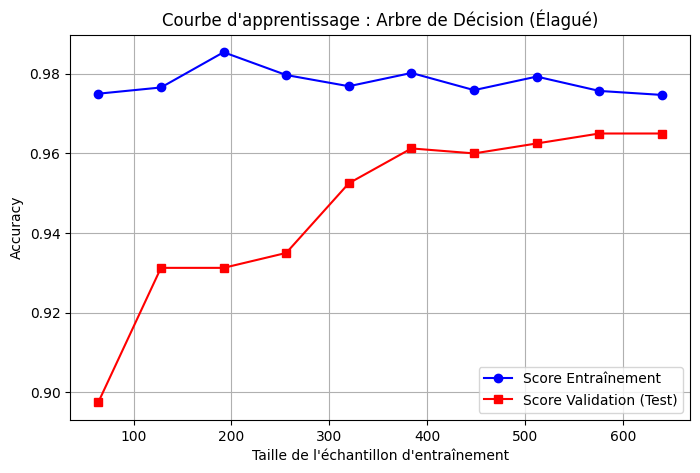

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# 1. Définition des hyperparamètres pour l'élagage (pruning)
param_grid_tree = {
    'max_depth': [3, 5, 10, None], # Limite la croissance pour éviter le surapprentissage
    'min_samples_leaf': [1, 5, 10, 20], # Nombre min de transactions pour créer une règle
    'criterion': ['gini', 'entropy'] # Mesure de la pureté des noeuds
}
# 2. Recherche du meilleur arbre
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='f1')
grid_tree.fit(X_train_scaled, y_train)
# 3. Résultats et scores
best_tree = grid_tree.best_estimator_
acc_train_tree = best_tree.score(X_train_scaled, y_train)
acc_test_tree = best_tree.score(X_test_scaled, y_test)
print(f"--- ARBRE DE DÉCISION ---")
print(f"Meilleurs paramètres : {grid_tree.best_params_}")
print(f"Accuracy Train : {acc_train_tree:.4f} | Accuracy Test : {acc_test_tree:.4f}")
print(f"Recall (Fraude) : {recall_score(y_test, best_tree.predict(X_test_scaled)):.4f}")
# 4. Courbe d'apprentissage
plot_individual_learning_curve(best_tree, X_train_scaled, y_train, "Arbre de Décision (Élagué)")

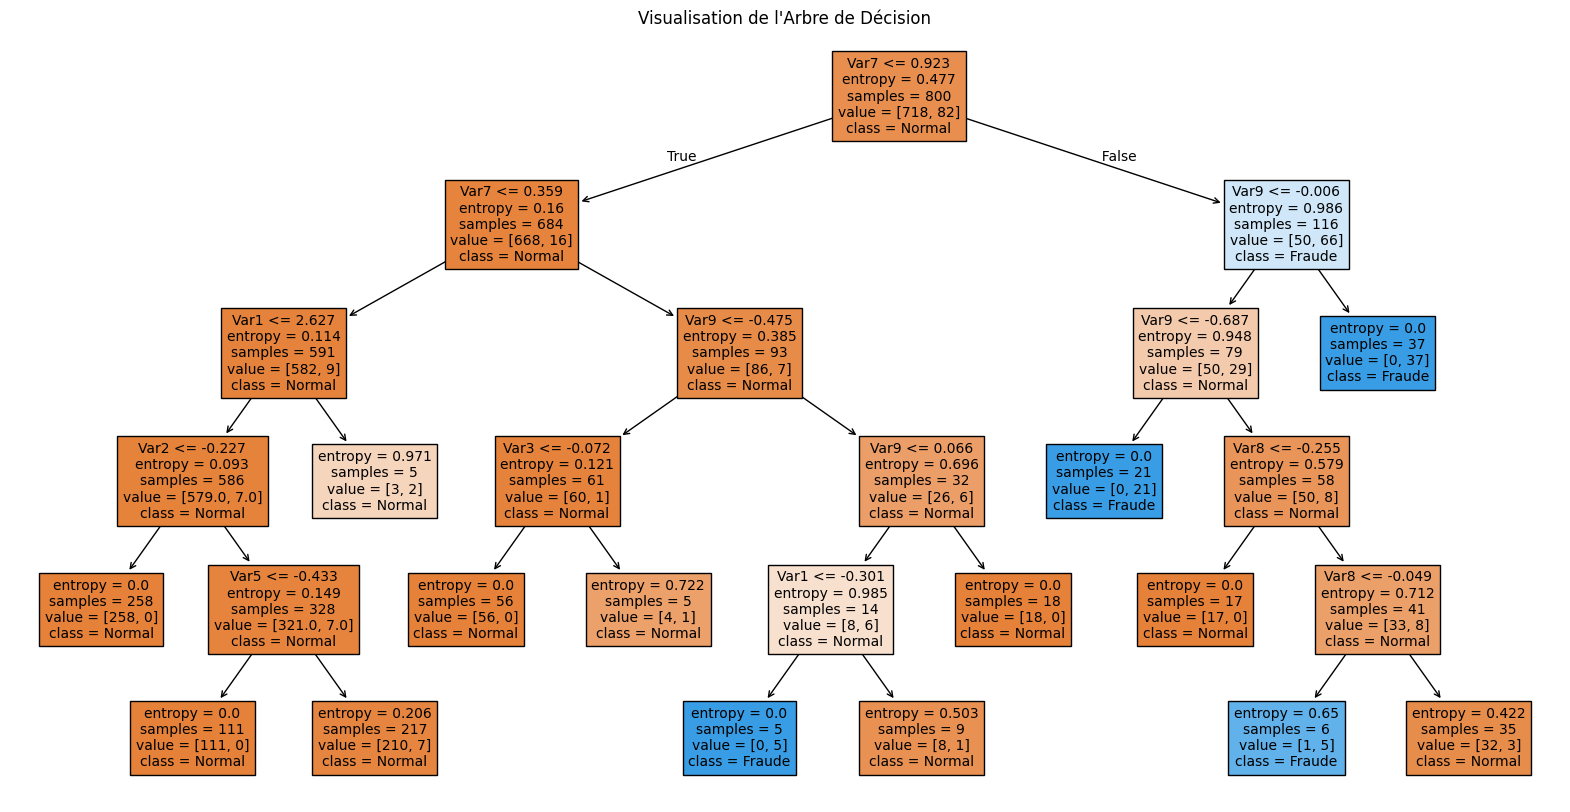

In [268]:
plt.figure(figsize=(20,10))
plot_tree(best_tree, filled=True, feature_names=['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10'], class_names=['Normal', 'Fraude'], fontsize=10)
plt.title("Visualisation de l'Arbre de Décision")
plt.show()